# nb11 - Clasificacion C-2: BETO fine-tuned (Bert en Espanol)

**Tarea:** clasificar documentos en `{Cedula, RUT, Poliza, CamaraComercio}`

**Modelo:** `dccuchile/bert-base-spanish-wwm-cased` (BETO, Canete et al. 2020) fine-tuned con HuggingFace Trainer.
Ver [PROPUESTA_MODELOS.md](https://github.com/) FASE 2 candidato C-2.

**Decisiones (alineadas con C-1 TF-IDF y C-3 LayoutLMv3 para comparacion justa):**
- Mismo split estratificado 70/15/15 con `random_state=42`
- Texto = concat de texto_ocr de las primeras 10 paginas
- Truncado a 512 tokens (limite BERT)
- 4 clases (sin Otros)

**Hardware:** Colab T4 GPU. Tiempo: ~30 min (carga modelo + 3 epochs).


## 1. Verificar GPU


In [1]:
import torch
assert torch.cuda.is_available(), 'Sin GPU. Runtime > Change runtime type > T4 GPU'
print(f'GPU: {torch.cuda.get_device_name(0)}')


GPU: Tesla T4


## 2. Instalar dependencias


In [2]:
!pip install -q transformers datasets accelerate evaluate scikit-learn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.9 MB/s eta 0:00:00


## 3. Montar Drive


In [3]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


## 4. Configuracion (paths + hiperparametros)


In [4]:
from pathlib import Path

DRIVE_BASE = Path('/content/drive/MyDrive/datasets/SinergiaLab')
CORPUS_CSV = DRIVE_BASE / 'processed' / 'corpus_ocr.csv'
MODELS_DIR = DRIVE_BASE / 'models' / 'c2_beto'
PREDS_CSV = DRIVE_BASE / 'processed' / 'c2_predictions.csv'
MODELS_DIR.mkdir(parents=True, exist_ok=True)

MODEL_NAME = 'dccuchile/bert-base-spanish-wwm-cased'
RANDOM_STATE = 42
TEST_SIZE = 0.15
VAL_SIZE = 0.15
MAX_LENGTH = 512
BATCH_SIZE = 16
LEARNING_RATE = 2e-5
N_EPOCHS = 3

assert CORPUS_CSV.exists(), f'NOT FOUND: {CORPUS_CSV}'
print(f'Corpus: {CORPUS_CSV}')
print(f'Models out: {MODELS_DIR}')


Corpus: /content/drive/MyDrive/datasets/SinergiaLab/processed/corpus_ocr.csv
Models out: /content/drive/MyDrive/datasets/SinergiaLab/models/c2_beto


## 5. Cargar corpus + agrupar por documento


In [5]:
import pandas as pd

df = pd.read_csv(CORPUS_CSV, dtype={'md5': str, 'doc_id': str})
print(f'Filas: {len(df):,} | Docs unicos: {df["doc_id"].nunique()}')
print('Engines:', df['engine'].value_counts().to_dict())

df['texto_ocr'] = df['texto_ocr'].fillna('')
docs = df.groupby('doc_id').agg(
    texto=('texto_ocr', lambda s: '\n'.join(s)),
    folder=('folder', 'first'),
).reset_index()
print(f'Documentos agrupados: {len(docs)}')


Filas: 5,351 | Docs unicos: 1134
Engines: {'easyocr': 5351}
Documentos agrupados: 1134


## 6. Normalizar etiquetas (mismo mapping que nb10)


In [6]:
def normalizar_clase(folder):
    s = str(folder).lower()
    if 'cedul' in s: return 'Cedula'
    if 'mara' in s: return 'CamaraComercio'
    if 'liza' in s: return 'Poliza'
    if s == 'rut': return 'RUT'
    return 'OTRO'

docs['clase'] = docs['folder'].apply(normalizar_clase)
docs = docs[docs['clase'] != 'OTRO'].copy()
docs = docs[docs['texto'].str.strip() != ''].copy()

CLASES = sorted(docs['clase'].unique())
label2id = {c: i for i, c in enumerate(CLASES)}
id2label = {i: c for c, i in label2id.items()}
docs['label'] = docs['clase'].map(label2id)

print('Clases:', CLASES)
print(docs['clase'].value_counts().to_string())


Clases: ['CamaraComercio', 'Cedula', 'Poliza', 'RUT']
clase
Cedula            518
RUT               212
Poliza            198
CamaraComercio    187


## 7. Split (mismo random_state que nb10)


In [7]:
from sklearn.model_selection import train_test_split

X_temp, X_test, y_temp, y_test = train_test_split(
    docs['texto'], docs['label'],
    test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=docs['clase'],
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=VAL_SIZE / (1 - TEST_SIZE), random_state=RANDOM_STATE, stratify=y_temp,
)

print(f'Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}')


Train: 779 | Val: 168 | Test: 168


## 8. Tokenizar con BETO


In [8]:
from transformers import AutoTokenizer
from datasets import Dataset

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_fn(batch):
    return tokenizer(batch['text'], truncation=True, padding=False, max_length=MAX_LENGTH)

def df_to_ds(X, y):
    return Dataset.from_dict({'text': X.tolist(), 'label': y.tolist()})

ds_train = df_to_ds(X_train, y_train).map(tokenize_fn, batched=True)
ds_val   = df_to_ds(X_val, y_val).map(tokenize_fn, batched=True)
ds_test  = df_to_ds(X_test, y_test).map(tokenize_fn, batched=True)

ds_train.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])
ds_val.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])
ds_test.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])

print(f'Tokenized: train={len(ds_train)}, val={len(ds_val)}, test={len(ds_test)}')


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/648 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/364 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/134 [00:00<?, ?B/s]

Map:   0%|          | 0/779 [00:00<?, ? examples/s]

Map:   0%|          | 0/168 [00:00<?, ? examples/s]

Map:   0%|          | 0/168 [00:00<?, ? examples/s]

Tokenized: train=779, val=168, test=168


## 9. Cargar modelo BETO


In [9]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(CLASES),
    id2label=id2label,
    label2id=label2id,
)
print(f'Modelo cargado: {MODEL_NAME} | num_labels: {len(CLASES)}')


pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
bert.pooler.dense.bias                     | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not 

Modelo cargado: dccuchile/bert-base-spanish-wwm-cased | num_labels: 4


## 10. Setup Trainer + entrenamiento


In [11]:
from transformers import TrainingArguments, Trainer, DataCollatorWithPadding
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy': accuracy_score(labels, preds),
        'macro_f1': f1_score(labels, preds, average='macro'),
        'weighted_f1': f1_score(labels, preds, average='weighted'),
    }

training_args = TrainingArguments(
    output_dir='/content/c2_beto_checkpoints',
    num_train_epochs=N_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='macro_f1',
    logging_steps=20,
    save_total_limit=1,
    seed=RANDOM_STATE,
    fp16=True,
    report_to='none',
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=ds_train,
    eval_dataset=ds_val,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

import time
t0 = time.time()
trainer.train()
elapsed_train = time.time() - t0
print(f'Entrenamiento completado en {elapsed_train/60:.1f} min')

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,0.094370,0.022460,0.994048,0.991356,0.994042
2,0.069677,0.009124,1.000000,1.000000,1.000000
3,0.029217,0.007503,1.000000,1.000000,1.000000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Entrenamiento completado en 1.6 min


## 11. Evaluacion en test


In [12]:
test_results = trainer.evaluate(eval_dataset=ds_test)
print('=== TEST ===')
for k, v in test_results.items():
    print(f'  {k}: {v:.4f}' if isinstance(v, float) else f'  {k}: {v}')


=== TEST ===
  eval_loss: 0.0139
  eval_accuracy: 0.9940
  eval_macro_f1: 0.9914
  eval_weighted_f1: 0.9940
  eval_runtime: 1.3045
  eval_samples_per_second: 128.7810
  eval_steps_per_second: 8.4320
  epoch: 3.0000


In [13]:
from sklearn.metrics import classification_report, confusion_matrix

preds_logits = trainer.predict(ds_test)
y_test_pred = np.argmax(preds_logits.predictions, axis=-1)
y_test_true = preds_logits.label_ids

y_test_pred_str = [id2label[i] for i in y_test_pred]
y_test_true_str = [id2label[i] for i in y_test_true]

print(classification_report(y_test_true_str, y_test_pred_str, digits=4))


                precision    recall  f1-score   support

CamaraComercio     1.0000    0.9643    0.9818        28
        Cedula     1.0000    1.0000    1.0000        78
        Poliza     0.9677    1.0000    0.9836        30
           RUT     1.0000    1.0000    1.0000        32

      accuracy                         0.9940       168
     macro avg     0.9919    0.9911    0.9914       168
  weighted avg     0.9942    0.9940    0.9940       168



## 12. Matriz de confusion


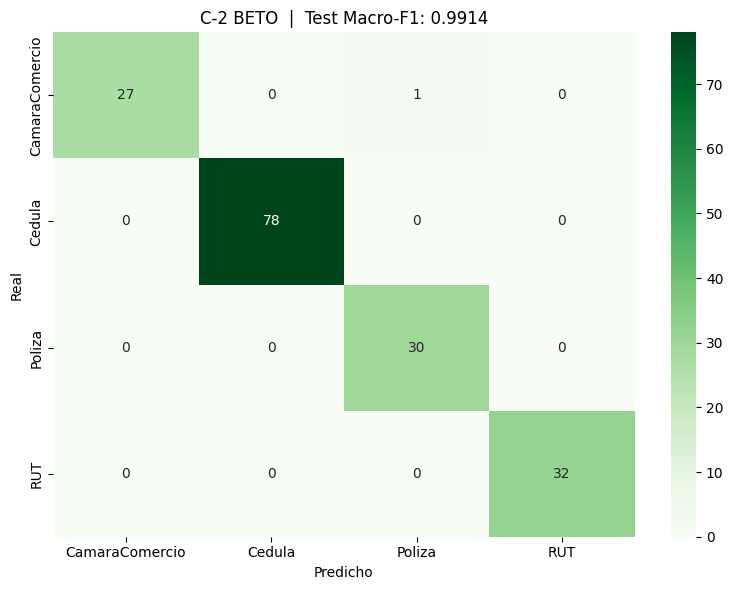

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test_true_str, y_test_pred_str, labels=CLASES)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=CLASES, yticklabels=CLASES, ax=ax)
ax.set_xlabel('Predicho')
ax.set_ylabel('Real')
ax.set_title(f'C-2 BETO  |  Test Macro-F1: {test_results["eval_macro_f1"]:.4f}')
plt.tight_layout()
plt.savefig('/content/fig_nb11_confusion.png', dpi=120, bbox_inches='tight')
plt.show()


## 13. Guardar modelo + predicciones a Drive


In [15]:
import json

trainer.save_model(str(MODELS_DIR))
tokenizer.save_pretrained(str(MODELS_DIR))
print(f'Modelo + tokenizer guardados en {MODELS_DIR}')

preds_df = pd.DataFrame({
    'doc_id': X_test.index.map(lambda i: docs.loc[i, 'doc_id']),
    'y_true': y_test_true_str,
    'y_pred': y_test_pred_str,
})
preds_df.to_csv(PREDS_CSV, index=False, encoding='utf-8')
print(f'Predicciones: {PREDS_CSV}')

summary = {
    'model': 'C-2 BETO fine-tuned',
    'model_name': MODEL_NAME,
    'random_state': RANDOM_STATE,
    'n_train': int(len(X_train)),
    'n_val': int(len(X_val)),
    'n_test': int(len(X_test)),
    'classes': CLASES,
    'max_length': MAX_LENGTH,
    'batch_size': BATCH_SIZE,
    'learning_rate': LEARNING_RATE,
    'n_epochs': N_EPOCHS,
    'training_time_min': float(elapsed_train / 60),
    'test_accuracy': float(test_results['eval_accuracy']),
    'test_macro_f1': float(test_results['eval_macro_f1']),
    'test_weighted_f1': float(test_results['eval_weighted_f1']),
}
with open(MODELS_DIR / 'metrics.json', 'w') as f:
    json.dump(summary, f, indent=2)
print(f'Resumen: {summary}')


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Modelo + tokenizer guardados en /content/drive/MyDrive/datasets/SinergiaLab/models/c2_beto
Predicciones: /content/drive/MyDrive/datasets/SinergiaLab/processed/c2_predictions.csv
Resumen: {'model': 'C-2 BETO fine-tuned', 'model_name': 'dccuchile/bert-base-spanish-wwm-cased', 'random_state': 42, 'n_train': 779, 'n_val': 168, 'n_test': 168, 'classes': ['CamaraComercio', 'Cedula', 'Poliza', 'RUT'], 'max_length': 512, 'batch_size': 16, 'learning_rate': 2e-05, 'n_epochs': 3, 'training_time_min': 1.5702178001403808, 'test_accuracy': 0.9940476190476191, 'test_macro_f1': 0.9913561847988077, 'test_weighted_f1': 0.9940422965013129}


## 14. Conclusion + comparacion contra C-1

Para comparar con C-1 (TF-IDF), descarga este `metrics.json` y compara `test_macro_f1`.

**Criterio del paper:** BETO debe superar a C-1 en al menos +5 puntos de macro-F1 para justificar su costo computacional.

**Siguiente paso:** ejecutar `nb12_clasificacion_C3_layoutlmv3.ipynb` (LayoutLMv3 con imagen + texto + bboxes) para el experimento 3.
